In [1]:
# Loading the cleaned dataset and prepare it for exploratory analysis.
# Adding a 'Year' column to enable year-level grouping and comparison

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Global_Sales_Performance_Cleaned.csv")

df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

# Generating summary statistics across key dimensions (region, category,
# year, country, and average order value) to establish the analytical baseline.

print("Shape:", df.shape)
print("\n--- Revenue by Region ---")
print(df.groupby("Region")["Total_Revenue"].sum().sort_values(ascending=False))

print("\n--- Revenue by Product Category ---")
print(df.groupby("Product_Category")["Total_Revenue"].sum().sort_values(ascending=False))

print("\n--- Revenue by Year ---")
print(df.groupby("Year")["Total_Revenue"].sum())

print("\n--- Top 5 Countries by Revenue ---")
print(df.groupby("Country")["Total_Revenue"].sum().sort_values(ascending=False).head(5))

print("\n--- Average Order Value by Category ---")
print(df.groupby("Product_Category")["Total_Revenue"].mean().sort_values(ascending=False))

Shape: (6672, 12)

--- Revenue by Region ---
Region
Europe           59573121.62
Asia-Pacific     58989789.86
Latin America    55866609.43
Middle East      54600696.66
North America    54435335.22
Name: Total_Revenue, dtype: float64

--- Revenue by Product Category ---
Product_Category
Raw Materials           2.017948e+08
Industrial Equipment    2.422240e+07
Food & Beverage         1.186920e+07
Electronics             1.146128e+07
Apparel & Footwear      1.006023e+07
Automotive Parts        9.185506e+06
Consumer Goods          8.357412e+06
Pharmaceuticals         6.514691e+06
Name: Total_Revenue, dtype: float64

--- Revenue by Year ---
Year
2022    99414711.81
2023    93532342.13
2024    90518498.85
Name: Total_Revenue, dtype: float64

--- Top 5 Countries by Revenue ---
Country
United States    18714760.13
Mexico           18555197.94
Canada           17165377.15
Israel           13953977.42
India            13566285.33
Name: Total_Revenue, dtype: float64

--- Average Order Value by Ca

In [2]:
# Displaying the full numbers on the axis labels.

plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-99, 99)

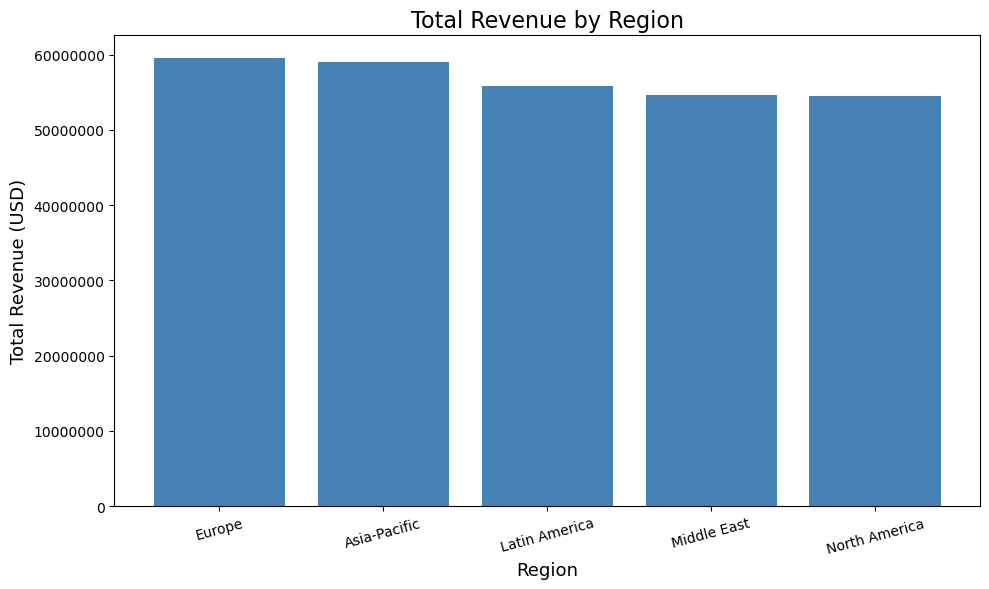

In [3]:
# Visualizing total revenue by region to identify any leading and trailing markets.

plt.figure(figsize=(10, 6))
revenue_by_region = df.groupby("Region")["Total_Revenue"].sum().sort_values(ascending=False)
plt.bar(revenue_by_region.index, revenue_by_region.values, color="steelblue")
plt.title("Total Revenue by Region", fontsize=16)
plt.xlabel("Region", fontsize=13)
plt.ylabel("Total Revenue (USD)", fontsize=13)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

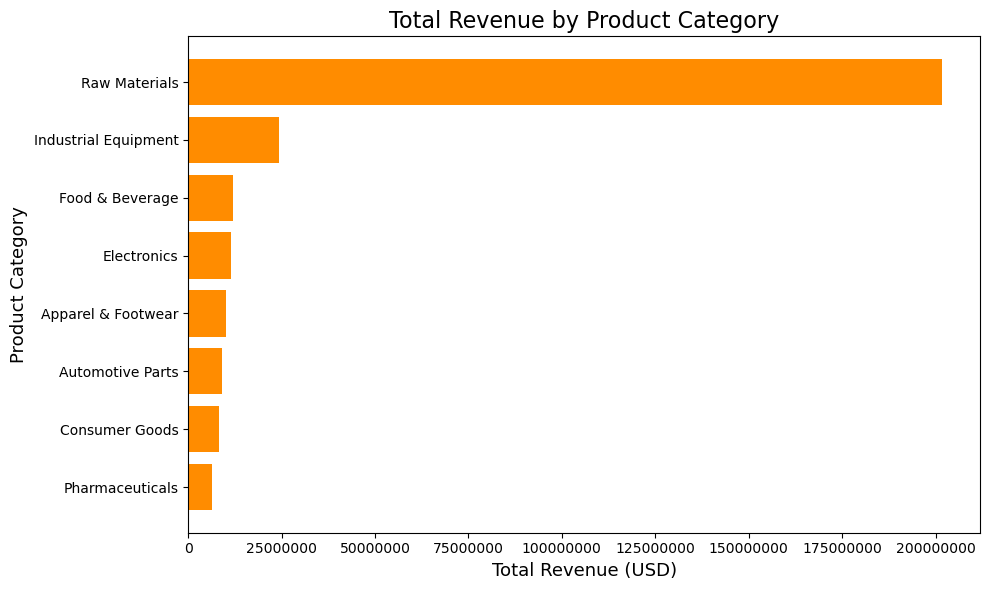

In [4]:
# Visualizing total revenue by product category to identify top, bottom performers.

plt.figure(figsize=(10, 6))
revenue_by_category = df.groupby("Product_Category")["Total_Revenue"].sum().sort_values()
plt.barh(revenue_by_category.index, revenue_by_category.values, color="darkorange")
plt.title("Total Revenue by Product Category", fontsize=16)
plt.xlabel("Total Revenue (USD)", fontsize=13)
plt.ylabel("Product Category", fontsize=13)
plt.tight_layout()
plt.show()

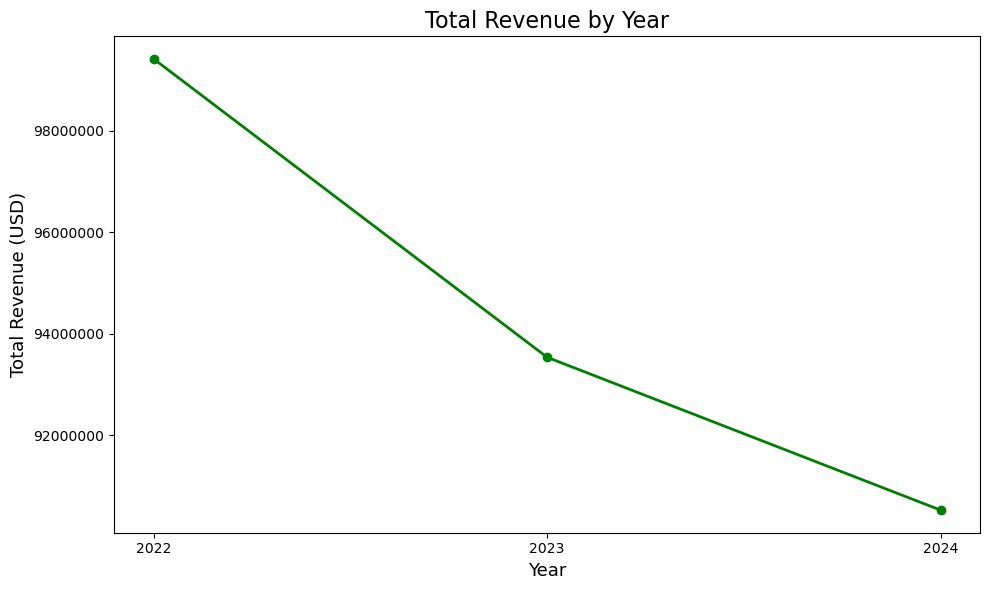

In [5]:
# Visualizing the annual revenue trend to surface the year-over-year decline pattern.

plt.figure(figsize=(10, 6))
revenue_by_year = df.groupby("Year")["Total_Revenue"].sum()
plt.plot(revenue_by_year.index, revenue_by_year.values, marker="o", color="green", linewidth=2)
plt.title("Total Revenue by Year", fontsize=16)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Total Revenue (USD)", fontsize=13)
plt.xticks(revenue_by_year.index)
plt.tight_layout()
plt.show()

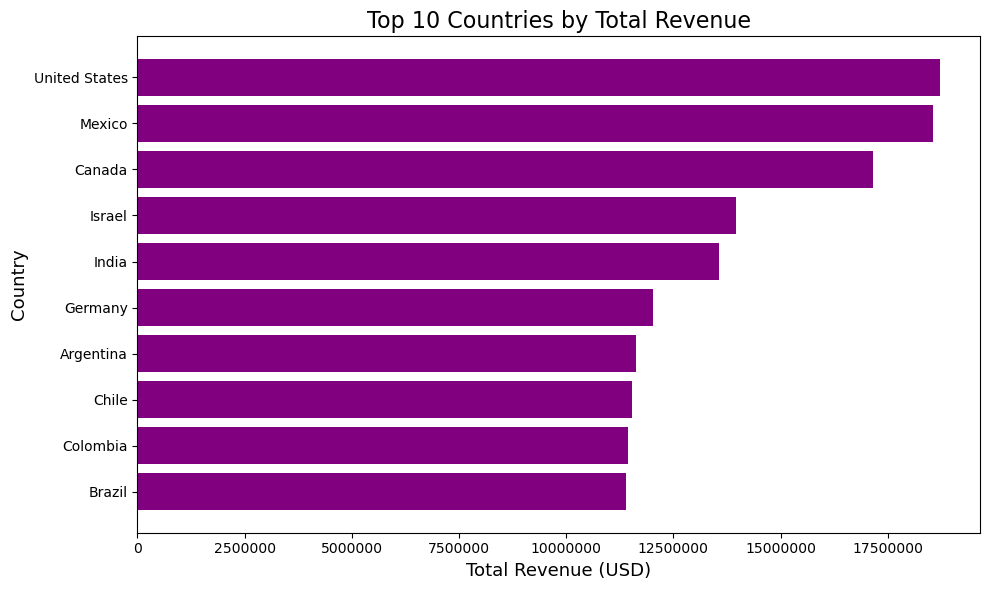

In [6]:
# Expanding country analysis to the top 10. North American countries dominate the
# top 5 despite the region trailing Europe and Asia-Pacific in aggregate revenue.


plt.figure(figsize=(10, 6))
top_countries = df.groupby("Country")["Total_Revenue"].sum().sort_values(ascending=False).head(10)
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color="purple")
plt.title("Top 10 Countries by Total Revenue", fontsize=16)
plt.xlabel("Total Revenue (USD)", fontsize=13)
plt.ylabel("Country", fontsize=13)
plt.tight_layout()
plt.show()

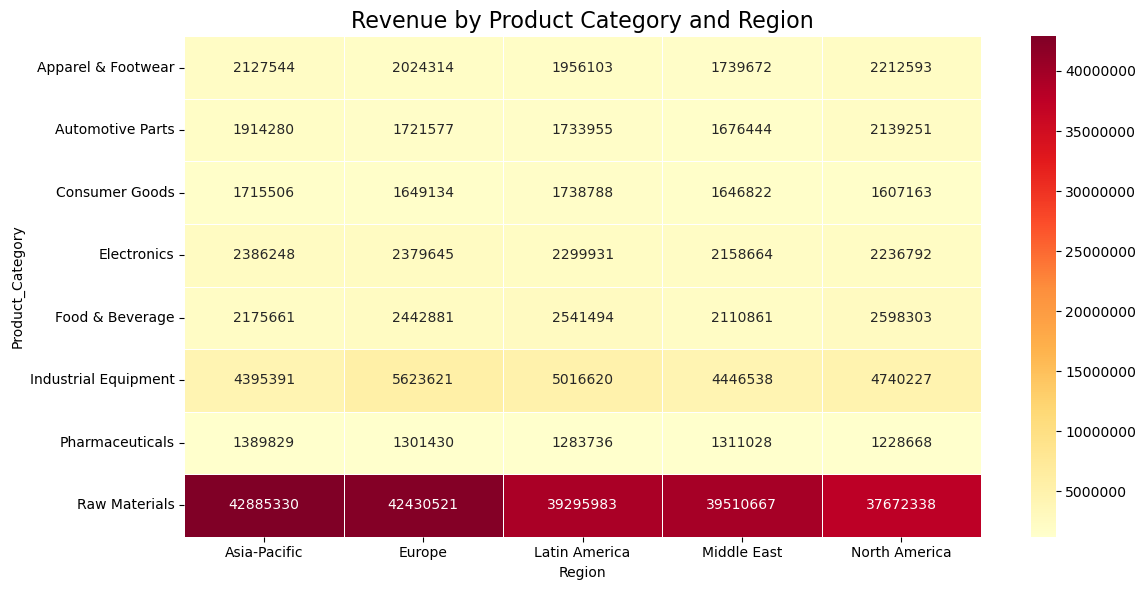

In [7]:
# Visualizing revenue by product category and region simultaneously using a heatmap
# to identify whether Raw Materials dominance is consistent across all regions.

plt.figure(figsize=(12, 6))
heatmap_data = df.pivot_table(index="Product_Category", columns="Region", values="Total_Revenue", aggfunc="sum")
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("Revenue by Product Category and Region", fontsize=16)
plt.tight_layout()
plt.show()

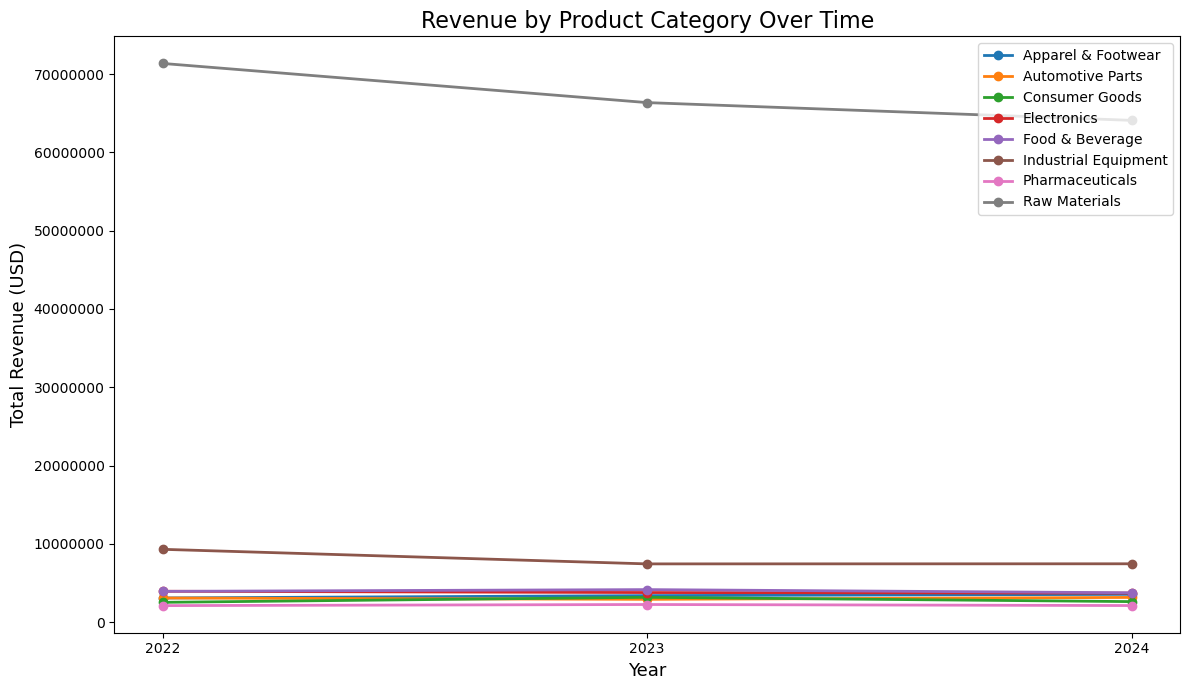

In [8]:
# Plotting revenue trends by product category over time to identify which categories
# are driving overall revenue decline.

plt.figure(figsize=(12, 7))
revenue_category_year = df.groupby(["Year", "Product_Category"])["Total_Revenue"].sum().unstack()
for column in revenue_category_year.columns:
    plt.plot(revenue_category_year.index, revenue_category_year[column], marker="o", linewidth=2, label=column)
plt.title("Revenue by Product Category Over Time", fontsize=16)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Total Revenue (USD)", fontsize=13)
plt.xticks(revenue_category_year.index)
plt.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

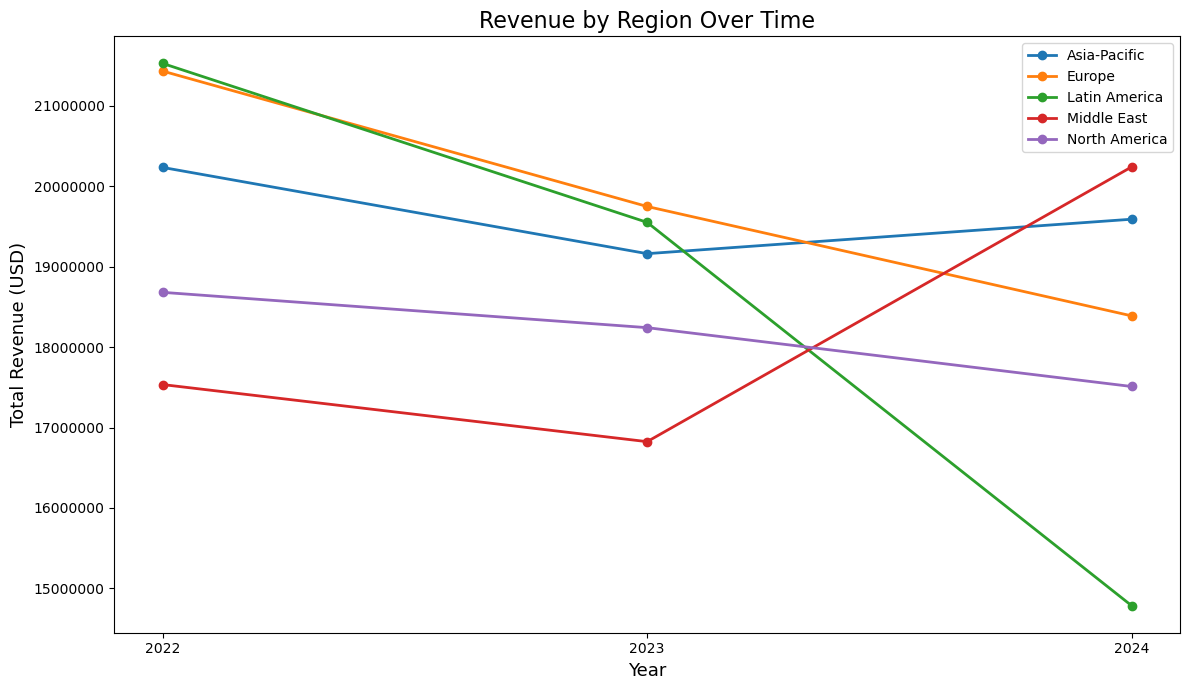

In [9]:
# Raw Materials and Industrial Equipment are both heavily affected by the drop in sales
# and are pulling down revenue. This chart investigates whether those declines are isolated to specific regions
# or represent a global trend across all markets.

plt.figure(figsize=(12, 7))
revenue_region_year = df.groupby(["Year", "Region"])["Total_Revenue"].sum().unstack()
for column in revenue_region_year.columns:
    plt.plot(revenue_region_year.index, revenue_region_year[column], marker="o", linewidth=2, label=column)
plt.title("Revenue by Region Over Time", fontsize=16)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Total Revenue (USD)", fontsize=13)
plt.xticks(revenue_region_year.index)
plt.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

In [10]:
# Generating a pivot table of revenue by year and product category to confirm
# the findings from the line charts above and validate against SQL results.

import pandas as pd

df = pd.read_csv("Global_Sales_Performance_Cleaned.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

pivot = df.groupby(["Year", "Product_Category"])["Total_Revenue"].sum().unstack()
pivot["Total"] = pivot.sum(axis=1)
print(pivot.round(2).to_string())

Product_Category  Apparel & Footwear  Automotive Parts  Consumer Goods  Electronics  Food & Beverage  Industrial Equipment  Pharmaceuticals  Raw Materials        Total
Year                                                                                                                                                                   
2022                      3100003.19        3092235.21      2540310.35   3954637.09       3941423.86            9309952.35       2121851.13    71354298.63  99414711.81
2023                      3399258.78        2925042.44      3183957.08   3790709.56       4166345.25            7450039.54       2263181.80    66353807.68  93532342.13
2024                      3560963.10        3168228.48      2633144.52   3715933.94       3761431.89            7462405.27       2129658.28    64086733.37  90518498.85


In [11]:
print("Final shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print(df.columns.tolist())
df.to_csv("Global_Sales_Performance_Cleaned.csv", index=False)
print("Saved successfully.")

Final shape: (6672, 12)
Missing values: 0
['Order_ID', 'Date', 'Region', 'Country', 'Product_Category', 'Product_Name', 'Units_Sold', 'Unit_Price', 'Total_Revenue', 'Sales_Rep', 'Currency', 'Year']
Saved successfully.
